In [10]:
import os
import time
from dotenv import load_dotenv

load_dotenv()

key = os.environ.get("GROQ_API_KEY")
print(key[:10] if key else "КЛЮЧ НЕ ЗАГРУЗИЛСЯ (None)")

gsk_B9sQpO


In [11]:
results = {}  
PROMPT = "Объясни разницу между машинным обучением и LLM"

from groq import Groq
from openai import OpenAI


def call_groq():
    client = Groq(api_key=os.environ["GROQ_API_KEY"])
    start = time.time()
    response = client.chat.completions.create(
        model="openai/gpt-oss-20b",
        messages=[{"role": "user", "content": PROMPT}],
    )
    elapsed = time.time() - start
    return response.choices[0].message.content, elapsed, response.usage.total_tokens

def call_openrouter():
    client = OpenAI(base_url="https://openrouter.ai/api/v1", api_key=os.environ["OPENROUTER_API_KEY"])
    start = time.time()
    response = client.chat.completions.create(
        model="openrouter/free",
        messages=[{"role": "user", "content": PROMPT}],
    )
    elapsed = time.time() - start
    return response.choices[0].message.content, elapsed, response.usage.total_tokens

for name, fn in [("Groq", call_groq), ("OpenRouter", call_openrouter)]:
    try:
        text, elapsed, tokens = fn()
        results[name] = {"time": elapsed, "tokens": tokens}  
        print(f"\n=== {name} ===")
        print(f"Время: {elapsed:.2f} сек | Токенов: {tokens}")
        print(text[:200], "...")
    except Exception as e:
        print(f"\n=== {name}: ОШИБКА ===")
        print(e)


=== Groq ===
Время: 2.85 сек | Токенов: 1961
## Машинное обучение (ML) – что это?

Машинное обучение — это **полный набор методов, подходов и задач**, которые позволяют компьютерам «учиться» из данных, а не быть запрограммированными вручную. В р ...

=== OpenRouter ===
Время: 12.73 сек | Токенов: 2752
Чтобы понять разницу между машинным обучением (ML) и большими языковыми моделями (LLM), нужно представить себе отношение **животного к конкретному виду**. Например, LLM — это разновидность собаки, а м ...


In [12]:
from google import genai

def call_gemini(retries=3, delay=5):
    client = genai.Client(api_key=os.environ["GOOGLE_API_KEY"])
    for attempt in range(retries):
        try:
            start = time.time()
            response = client.models.generate_content(
                model="gemini-3.6-flash",
                contents=PROMPT,
            )
            elapsed = time.time() - start
            return response.text, elapsed, response.usage_metadata.total_token_count
        except Exception as e:
            if attempt < retries - 1:
                print(f"Gemini перегружен, повтор через {delay} сек...")
                time.sleep(delay)
            else:
                raise

for name, fn in [("Gemini", call_gemini)]:
    try:
        text, elapsed, tokens = fn()
        results[name] = {"time": elapsed, "tokens": tokens}  # ← сохраняем сюда
        print(f"\n=== {name} ===")
        print(f"Время: {elapsed:.2f} сек | Токенов: {tokens}")
        print(text[:200], "...")
    except Exception as e:
        print(f"\n=== {name}: ОШИБКА ===")
        print(e)


=== Gemini ===
Время: 14.52 сек | Токенов: 2097
Главное различие между ними можно сформулировать так: **Машинное обучение (ML) — это огромная область науки, а LLM — это один конкретный узкоспециализированный инструмент внутри этой области.**

Проще ...


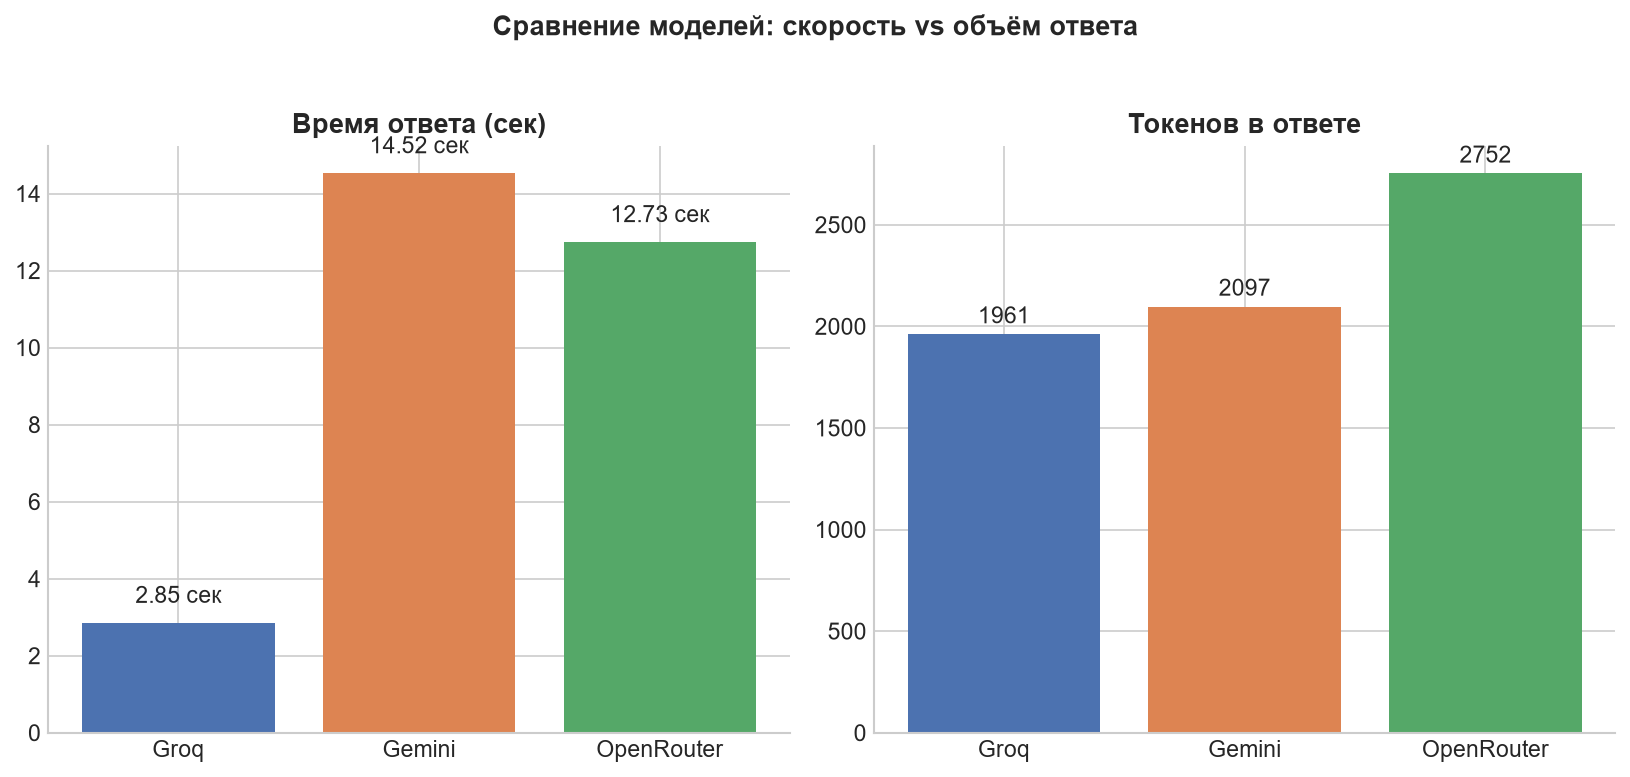

In [13]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 150, 'font.size': 11,
                      'axes.titlesize': 13, 'axes.titleweight': 'bold'})

order = ["Groq", "Gemini", "OpenRouter"]
names = [n for n in order if n in results]  
times = [results[n]["time"] for n in names]
tokens = [results[n]["tokens"] for n in names]
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

bars1 = ax1.bar(names, times, color=colors[:len(names)])
for bar in bars1:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 0.4, f'{h:.2f} сек', ha='center', va='bottom')
ax1.set_title('Время ответа (сек)')
ax1.spines[['top', 'right']].set_visible(False)

bars2 = ax2.bar(names, tokens, color=colors[:len(names)])
for bar in bars2:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 30, f'{int(h)}', ha='center', va='bottom')
ax2.set_title('Токенов в ответе')
ax2.spines[['top', 'right']].set_visible(False)

fig.suptitle('Сравнение моделей: скорость vs объём ответа', fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()